In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from datetime import datetime

In [2]:
df = pd.read_csv("updated.csv")

In [3]:
df.tail()

,Unnamed: 0,Owning Subsidiary (Marketing Project) (Marketing Project),Task ID,Service Type,Audience (Marketing Project) (Marketing Project),Created On,Service Task Type,Platform,Service Line (Service Type) (MASH Service)
43949,43949,Denmark,ST1401881,Targeted List Pull,Commercial,2024-12-03 02:24:36,List Pull Setup,UCMP,Lead Acquisition & Engagement
43950,43950,Denmark,ST1401873,Targeted List Pull,Commercial,2024-12-03 02:19:08,List Pull Setup,UCMP,Lead Acquisition & Engagement
43951,43951,Spain,ST1401388,Targeted List Pull,Commercial,2024-12-02 16:25:03,List Pull Setup,UCMP,Lead Acquisition & Engagement
43952,43952,WE HQ,ST1401043,Targeted List Pull,Commercial,2024-12-02 06:09:38,List Hygiene,UCMP,Lead Acquisition & Engagement
43953,43953,WE HQ,ST1400563,Targeted List Pull,Commercial,2024-12-01 23:33:52,List Hygiene,UCMP,Lead Acquisition & Engagement


In [4]:
# converting Created on to datetime
df['Created On'] = pd.to_datetime(df['Created On'], errors='coerce')

In [5]:
df['Year'] = df['Created On'].dt.year
df['Month'] = df['Created On'].dt.month

In [6]:
df['YearMonth'] = df['Created On'].dt.to_period('M').astype(str)

In [7]:
df

,Unnamed: 0,Owning Subsidiary (Marketing Project) (Marketing Project),Task ID,Service Type,Audience (Marketing Project) (Marketing Project),Created On,Service Task Type,Platform,Service Line (Service Type) (MASH Service),Year,Month,YearMonth
0,0,Australia,ST789891,Targeted List Pull,Commercial,2023-01-15 18:33:43,Campaign Counts,Marketo,Lead Acquisition & Engagement,2023,1,2023-01
1,1,Australia,ST789922,Targeted List Pull,Commercial,2023-01-15 20:34:04,Campaign Counts,Marketo,Lead Acquisition & Engagement,2023,1,2023-01
2,2,Australia,ST791779,Targeted List Pull,Commercial,2023-01-17 18:04:34,Campaign Counts,Marketo,Lead Acquisition & Engagement,2023,1,2023-01
3,3,Australia,ST791834,Targeted List Pull,Commercial,2023-01-17 18:46:22,Campaign Counts,Marketo,Lead Acquisition & Engagement,2023,1,2023-01
4,4,Australia,ST791971,Targeted List Pull,Commercial,2023-01-17 23:34:41,Campaign Counts,Marketo,Lead Acquisition & Engagement,2023,1,2023-01
...,...,...,...,...,...,...,...,...,...,...,...,...
43949,43949,Denmark,ST1401881,Targeted List Pull,Commercial,2024-12-03 02:24:36,List Pull Setup,UCMP,Lead Acquisition & Engagement,2024,12,2024-12
43950,43950,Denmark,ST1401873,Targeted List Pull,Commercial,2024-12-03 02:19:08,List Pull Setup,UCMP,Lead Acquisition & Engagement,2024,12,2024-12
43951,43951,Spain,ST1401388,Targeted List Pull,Commercial,2024-12-02 16:25:03,List Pull Setup,UCMP,Lead Acquisition & Engagement,2024,12,2024-12
43952,43952,WE HQ,ST1401043,Targeted List Pull,Commercial,2024-12-02 06:09:38,List Hygiene,UCMP,Lead Acquisition & Engagement,2024,12,2024-12


In [8]:
grouped = df.groupby(['YearMonth',
    'Owning Subsidiary (Marketing Project) (Marketing Project)',
    'Service Type',
    'Audience (Marketing Project) (Marketing Project)',
    'Service Task Type',
    'Platform',
    'Service Line (Service Type) (MASH Service)'
]).agg(TaskCount=('Task ID', 'count')).reset_index()
grouped.head()

,YearMonth,Owning Subsidiary (Marketing Project) (Marketing Project),Service Type,Audience (Marketing Project) (Marketing Project),Service Task Type,Platform,Service Line (Service Type) (MASH Service),TaskCount
0,2022-01,ESI Asia,Marketing Contact Management,Commercial,Lead upload,Marketo,Lead Acquisition & Engagement,1
1,2022-01,LATAM HQ,Marketing Contact Management,Commercial,Lead upload,Marketo,Lead Acquisition & Engagement,1
2,2022-02,Germany,Marketing Contact Management,Commercial,UCMP Profile Upload,UCMP,Lead Acquisition & Engagement,1
3,2022-02,Germany,Marketing Contact Management,Commercial,UCMP Profile Validation,UCMP,Lead Acquisition & Engagement,1
4,2022-03,ASEAN HQ,Marketing Contact Management,Commercial,UCMP Profile Validation,UCMP,Lead Acquisition & Engagement,2


In [9]:
grouped['Year'] = pd.to_datetime(grouped['YearMonth']).dt.year
grouped['Month'] = pd.to_datetime(grouped['YearMonth']).dt.month

In [10]:
X = grouped.drop(columns=['TaskCount', 'YearMonth'])
y = grouped['TaskCount']

categorical_cols = [
    'Owning Subsidiary (Marketing Project) (Marketing Project)',
    'Service Type',
    'Audience (Marketing Project) (Marketing Project)',
    'Service Task Type',
    'Platform',
    'Service Line (Service Type) (MASH Service)',
    'Year',
    'Month'
]

In [11]:
pipeline = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ])
    ),
    ('regressor', LinearRegression())
])

# # One-hot encode the categorical columns manually
# encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
# X_encoded = encoder.fit_transform(X[categorical_cols])

# # Train a linear regression model
# model = LinearRegression()
# model.fit(X_encoded, y)

# # For prediction
# X_new_encoded = encoder.transform(X_new[categorical_cols])
# predictions = model.predict(X_new_encoded)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

print("Model R^2 Score:", pipeline.score(X_test, y_test))

Model R^2 Score: 0.41362612630001416


In [13]:
latest_year = df['Year'].max()
base_rows = df.copy()

top_combinations = (
    base_rows.groupby([
        'Owning Subsidiary (Marketing Project) (Marketing Project)',
        'Service Type',
        'Audience (Marketing Project) (Marketing Project)',
        'Service Task Type',
        'Platform',
        'Service Line (Service Type) (MASH Service)'
    ])
    .size()
    .reset_index()
    .rename(columns={0: 'Count'})
    .sort_values(by='Count', ascending=False)
    .head(10)
)


In [14]:
forecast_rows = []
for month in range(1, 13):
    for _, row in top_combinations.iterrows():
        forecast_rows.append({
            **row.drop('Count'),
            'Year': latest_year + 1,
            'Month': month
        })

forecast_df = pd.DataFrame(forecast_rows)

forecasted_tasks = pipeline.predict(forecast_df)
forecast_df['Predicted TaskCount'] = forecasted_tasks

monthly_forecast = forecast_df.groupby(['Year', 'Month'])['Predicted TaskCount'].sum().reset_index()


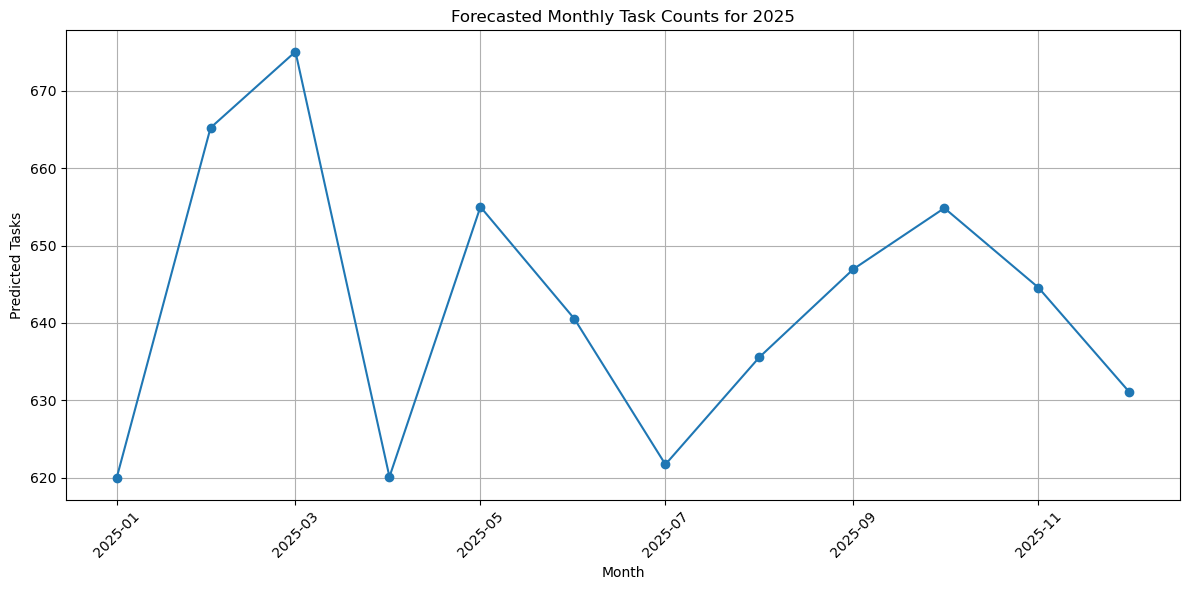

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(monthly_forecast['Year'].astype(str) + '-' + monthly_forecast['Month'].astype(str)), 
         monthly_forecast['Predicted TaskCount'], marker='o')
plt.title("Forecasted Monthly Task Counts for 2025")
plt.xlabel("Month")
plt.ylabel("Predicted Tasks")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


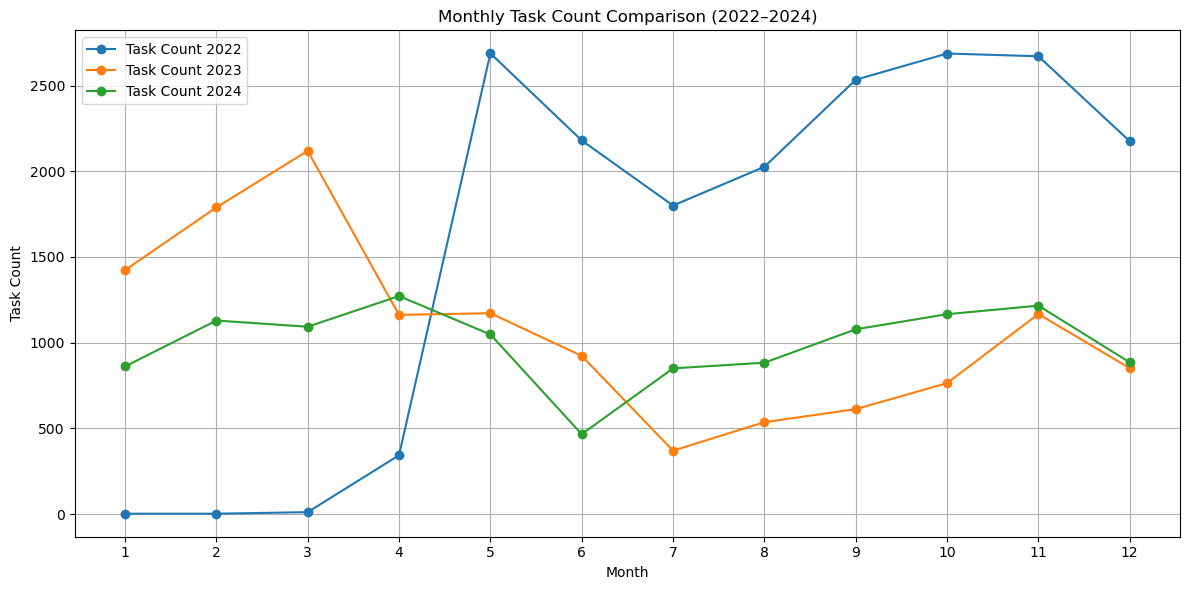

In [18]:
import matplotlib.pyplot as plt

# Extract year and month again in case not already present
# df['Year'] = df['Created On'].dt.year
# df['Month'] = df['Created On'].dt.month

# Filter for years 2022 to 2024
df_filtered = df[df['Year'].isin([2022, 2023, 2024])]

# Group by Year and Month, count Task IDs
monthly_counts = df_filtered.groupby(['Year', 'Month'])['Task ID'].count().reset_index()

# Pivot to have months as index and years as columns
pivot_df = monthly_counts.pivot(index='Month', columns='Year', values='Task ID')

# Plot
plt.figure(figsize=(12, 6))
for year in [2022, 2023, 2024]:
    if year in pivot_df.columns:
        plt.plot(pivot_df.index, pivot_df[year], marker='o', label=f'Task Count {year}')

plt.title("Monthly Task Count Comparison (2022–2024)")
plt.xlabel("Month")
plt.ylabel("Task Count")
plt.xticks(range(1, 13))  # Ensure months are 1–12
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
